# Clusterisation vectorielle et construction des cadrages médiatiques

**Mémoire de Master de Luca Panese, Université de Lausanne**

Ce notebook déroule l'intégralité de la chaîne d'analyse, du corpus de transcriptions TikTok jusqu'aux figures des résultats.

1. Chargement et filtrage du corpus
2. Embeddings sémantiques (Qwen3-Embedding-8B)
3. Réduction dimensionnelle (UMAP) et clustering (HDBSCAN) via le framework BERTopic
4. Extraction des mots-clés par cluster (c-TF-IDF)
5. Diagnostics de qualité, cohérence et documents représentatifs
6. Consolidation des topics en cadrages (revue qualitative et test d'Entman)
7. Résultats et visualisations (QR2 et QR3)

**Reproductibilité.** La chaîne comporte deux niveaux. La génération des embeddings (niveau 1) est exécutée une seule fois car très coûteux en puissance de calcul. Elle est fournie comme artefact (`embeddings_Qwen3-8b.npy`). Le niveau 2, pouvant être rerun simplement, couvre UMAP, HDBSCAN, la c-TF-IDF, la consolidation et les figures.


### Installation et importations

In [27]:
%pip install bertopic sentence-transformers umap-learn hdbscan pandas numpy scikit-learn

import json
import numpy as np
import pandas as pd
from pathlib import Path

#Sentencetransfromer pour les embeddings
from sentence_transformers import SentenceTransformer

#Composants du pipeline de BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

#BERTopic
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

#Reproductibilité: fixed seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Config. affichage pandas
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
# Versions des librairies (traçabilité et reproductibilité)
import bertopic, umap, hdbscan, sklearn, numpy, pandas, sentence_transformers
for _name, _mod in [("bertopic", bertopic), ("umap-learn", umap), ("hdbscan", hdbscan),
                    ("scikit-learn", sklearn), ("numpy", numpy), ("pandas", pandas),
                    ("sentence-transformers", sentence_transformers)]:
    print(f"{_name:22s} {getattr(_mod, '__version__', '?')}")


bertopic               0.17.4
umap-learn             0.5.12
hdbscan                ?
scikit-learn           1.8.0
numpy                  2.4.3
pandas                 2.3.3
sentence-transformers  5.5.1


### Chargement du corpus de données + aperçu

In [29]:
import sys

CLUSTERING_DIR = Path("")  # à compléter : dossier contenant les données (data/ : embeddings et CSV canoniques)
sys.path.insert(0, str(CLUSTERING_DIR))

from categorisation_comptes import BORD_POLITIQUE, ACTEUR_SYNTHESE_MAPPING

CORPUS_PATH = CLUSTERING_DIR / "corpus_cleaned_v1.json"

assert CORPUS_PATH.exists(), f"Fichier introuvable : {CORPUS_PATH.absolute()}"

with open(CORPUS_PATH, encoding='utf-8') as f:
    data = json.load(f)

videos = data['videos']
print(f"Vidéos chargées depuis le JSON : {len(videos)}")

df = pd.DataFrame(videos)

df['date'] = pd.to_datetime(df['create_time'], unit='s').dt.date

df['orientation_politique'] = df['username'].map(BORD_POLITIQUE)

df['orientation_politique_macro'] = df['orientation_politique'].map(lambda b: ACTEUR_SYNTHESE_MAPPING.get(b, b))

df['nb_mots'] = df['texte_clean'].str.split().str.len().fillna(0).astype(int)

print(f"\n=== DISTRIBUTION PAR acteur_type ===")
print(df['acteur_type'].value_counts())

print(f"\n=== DISTRIBUTION PAR orientation_politique ===")
print(df['orientation_politique'].value_counts())

print(f"\n=== DISTRIBUTION PAR orientation_politique_macro ===")
print(df['orientation_politique_macro'].value_counts())

print(f"\n=== DISTRIBUTION TEMPORELLE (par mois) ===")
print(df.groupby(pd.to_datetime(df['date']).dt.to_period('M')).size())

print(f"\nVidéos avec moins de 20 mots dans texte_clean : {(df['nb_mots'] < 20).sum()}")

print(f"\n=== APERÇU DU DATAFRAME ===")
print(f"Colonnes : {list(df.columns)}")
print(f"Shape : {df.shape}")
df[['username', 'acteur_type', 'orientation_politique', 'orientation_politique_macro', 'date', 'nb_mots']].head(10)

Vidéos chargées depuis le JSON : 701

=== DISTRIBUTION PAR acteur_type ===
acteur_type
media         571
politicien    130
Name: count, dtype: int64

=== DISTRIBUTION PAR orientation_politique ===
orientation_politique
Media-Centre            248
Media-Droite            108
Media-Gauche             82
Media-Régional           77
LFI                      73
Media-Extreme-Droite     56
RN                       16
Reconquête               11
LR                       10
LE                        7
LFH                       3
PS                        3
NPA                       2
LO                        2
Renaissance               1
Horizons                  1
PCF                       1
Name: count, dtype: int64

=== DISTRIBUTION PAR orientation_politique_macro ===
orientation_politique_macro
Media-Centre                  248
Media-Droite                  108
Media-Gauche                   82
Politicien-Gauche-Radicale     78
Media-Régional                 77
Media-Extreme-Droite       

,username,acteur_type,orientation_politique,orientation_politique_macro,date,nb_mots
0,zemmour_eric,politicien,Reconquête,Politicien-Extreme-Droite,2026-02-23,352
1,zemmour_eric,politicien,Reconquête,Politicien-Extreme-Droite,2026-02-22,178
2,zemmour_eric,politicien,Reconquête,Politicien-Extreme-Droite,2026-02-19,303
3,zemmour_eric,politicien,Reconquête,Politicien-Extreme-Droite,2026-02-15,242
4,sarah_knafo,politicien,Reconquête,Politicien-Extreme-Droite,2026-02-16,597
5,sarah_knafo,politicien,Reconquête,Politicien-Extreme-Droite,2026-03-11,243
6,rnational_off,politicien,RN,Politicien-Extreme-Droite,2026-02-27,333
7,rnational_off,politicien,RN,Politicien-Extreme-Droite,2026-02-21,322
8,jordanbardella,politicien,RN,Politicien-Extreme-Droite,2026-02-19,210
9,sebchenu,politicien,RN,Politicien-Extreme-Droite,2026-02-25,105


### Filtrage des transcriptions trop courtes

Les transcriptions de moins de 20 mots sont écartées. Trop pauvres, elles dégradent la qualité des embeddings et du clustering.


In [30]:
SEUIL_MOTS_MIN = 20

# Application du filtre
df_initial = df.copy()  # sauvegarde pour traçabilité
df = df[df['nb_mots'] >= SEUIL_MOTS_MIN].reset_index(drop=True)

n_exclus = len(df_initial) - len(df)
print(f"FILTRAGE:")
print(f"Vidéos avant filtre : {len(df_initial)}")
print(f"Vidéos après filtre (>= {SEUIL_MOTS_MIN} mots) : {len(df)}")
print(f"Vidéos exclues (< {SEUIL_MOTS_MIN} mots) : {n_exclus}")

# Affichage des vidéos exclues pour traçabilité
if n_exclus > 0:
    exclues = df_initial[df_initial['nb_mots'] < SEUIL_MOTS_MIN][
        ['username', 'acteur_type', 'orientation_politique', 'nb_mots', 'url_video']
    ]
    print(f"\nVIDÉOS EXCLUES:")
    print(exclues.to_string(index=False))


FILTRAGE:
Vidéos avant filtre : 701
Vidéos après filtre (>= 20 mots) : 697
Vidéos exclues (< 20 mots) : 4

VIDÉOS EXCLUES:
       username acteur_type orientation_politique  nb_mots                                                         url_video
    julienodoul  politicien                    RN       16     https://www.tiktok.com/@julienodoul/video/7607835216182316310
partisocialiste  politicien                    PS       13 https://www.tiktok.com/@partisocialiste/video/7604916625568992534
   manonaubryfr  politicien                   LFI       19    https://www.tiktok.com/@manonaubryfr/video/7614942333557099798
   brutofficiel       media          Media-Centre       19    https://www.tiktok.com/@brutofficiel/video/7609388095498177814


Préparation structures pour BERTopic. Explication des variables:
- textes: liste des string à embedder et clusteriser
- classes_politique : pour topics_per_class avec granularité fine
- classes_politiques_macro : pour topics_per_class avec granularité macro
- classes_acteur : pour topics_per_class avec distinction politicien/média

In [31]:
textes = df['texte_clean'].tolist()
classes_politique = df['orientation_politique'].tolist()
classes_politique_macro = df['orientation_politique_macro'].tolist()
classes_acteur = df['acteur_type'].tolist()

print(f"\n=== STRUCTURES PRÊTES POUR LE CLUSTERING ===")
print(f"Nombre de textes à clusteriser : {len(textes)}")
print(f"Longueur médiane des textes : {df['nb_mots'].median():.0f} mots")
print(f"Longueur min/max : {df['nb_mots'].min()} / {df['nb_mots'].max()} mots")

CSV_PATH = CLUSTERING_DIR / "corpus_pret_clustering.csv"
df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')
print(f"\nDataFrame filtré sauvegardé dans : {CSV_PATH}")
print(f"Shape final : {df.shape}")


=== STRUCTURES PRÊTES POUR LE CLUSTERING ===
Nombre de textes à clusteriser : 697
Longueur médiane des textes : 316 mots
Longueur min/max : 20 / 10359 mots

DataFrame filtré sauvegardé dans : /Users/lucapanese/MEMOIRE (local)/Scripts_memoire/Collecte_TikTok/clustering/corpus_pret_clustering.csv
Shape final : (697, 31)


### Génération des embeddings

### Choix du modèle d'embeddings

Le modèle retenu est **Qwen3-Embedding-8B** (Zhang et al., 2025). Le choix s'appuie sur le classement MMTEB (Massive Multilingual Text Embedding Benchmark), où les modèles Qwen3-Embedding figurent dans les dix premiers, avec des performances de clustering supérieures à celles de certains modèles pourtant mieux classés au global. La variante 8B (4096 dimensions) a été préférée à la variante 4B.

Ce modèle a été retenu de préférence à sentence-camembert-large, plus ancien, moins performant et incompatible avec transformers 5.x.

Références : MMTEB, https://doi.org/10.48550/arXiv.2502.13595 ; Qwen3-Embedding, https://doi.org/10.48550/arXiv.2506.05176


In [32]:
import time

EMBEDDINGS_PATH = CLUSTERING_DIR / "embeddings_Qwen3-8b.npy" #ADAPTER NOM FICHIER AU MODELE CHOISI!

if EMBEDDINGS_PATH.exists():
    print(f"Embeddings déjà calculés, chargement depuis {EMBEDDINGS_PATH}")
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Shape : {embeddings.shape}")
else:
    print("Chargement du modèle. Téléchargement au premier usage, mise en cache HuggingFace ensuite")

    embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-4B") #ADAPTER AU MODELE UTILISE!

    print(f"\nModèle chargé. Génération des embeddings pour {len(textes)} textes...")

    t0 = time.time()
    embeddings = embedding_model.encode(
        textes,
        batch_size=8,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    elapsed = time.time() - t0

    print(f"\nEmbeddings générés en {elapsed:.0f} secondes ({elapsed/60:.1f} min).")
    print(f"Shape : {embeddings.shape}")

    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Embeddings sauvegardés dans {EMBEDDINGS_PATH}")

print(f"\n=== VÉRIFICATIONS DES EMBEDDINGS ===")
print(f"Nombre d'embeddings : {embeddings.shape[0]} (doit = {len(textes)})")
print(f"Dimension des embeddings : {embeddings.shape[1]}")
print(f"Type : {embeddings.dtype}")
print(f"Norme moyenne (doit ≈ 1.0 car normalize_embeddings=True) : "
      f"{np.linalg.norm(embeddings, axis=1).mean():.3f}")

assert embeddings.shape[0] == len(textes), \
    "ERREUR : Désynchro entre embeddings et textes — recommencer la cellule"
assert embeddings.shape[1] == 1024 or embeddings.shape[1] == 4096 , \
    "ERREUR : Dimension inattendue — le modèle ne s'est pas chargé correctement"

print("\n TOUT OK => Embeddings prêts pour la suite du pipeline.")

Embeddings déjà calculés, chargement depuis /Users/lucapanese/MEMOIRE (local)/Scripts_memoire/Collecte_TikTok/clustering/embeddings_Qwen3-8b.npy
Shape : (697, 4096)

=== VÉRIFICATIONS DES EMBEDDINGS ===
Nombre d'embeddings : 697 (doit = 697)
Dimension des embeddings : 4096
Type : float32
Norme moyenne (doit ≈ 1.0 car normalize_embeddings=True) : 1.001

 TOUT OK => Embeddings prêts pour la suite du pipeline.


## Configuration framework BERTopic
Pipeline en 4 composants:
1. UMAP : réduction dimensionnelle des embeddings
2. HDBSCAN : clustering non-paramétrique
3. CountVectorizer : vocabulaire pour c-TF-IDF (stopwords français)
4. ClassTfidfTransformer : extraction des mots-clés représentatifs

Paramètres calibrés pour :
- Corpus modéré (~700 documents)
- Événement unique (faible variance inter-documents)
- Analyse exploratoire (on ne fixe pas le nombre de topics a priori)


In [33]:
#Liste des stopwords en français

french_stopwords = [
    "le", "la", "les", "de", "du", "des", "un", "une", "et", "en",
    "est", "que", "qui", "se", "sur", "par", "pas", "plus", "avec",
    "pour", "dans", "au", "aux", "ce", "cette", "ces", "son", "sa",
    "ses", "il", "elle", "ils", "elles", "nous", "vous", "on", "je",
    "tu", "me", "te", "lui", "y", "si", "ne", "à", "or", "mais",
    "donc", "or", "ni", "car", "très", "bien", "tout", "aussi",
    "même", "comme", "quand", "dont", "où", "leur", "leurs",
    "été", "avoir", "être", "faire", "dit", "fait", "va", "vais",
    "ça", "c'est", "qu'il", "qu'elle", "qu'on", "n'est", "c'était",
    "parce", "quoi", "alors", "voilà", "après", "avant", "entre",
    "pendant", "depuis", "sans", "sous", "entre", "vers", "chez"
]

### Composant 1: UMAP

Réduction des dimensions tout en préservant la structure locale (clusters sémantiques proches).

Paramètres clés :
- n_neighbors=10 : voisinage local plus petit que le défaut (15) car  corpus de taille moyenne
- n_components=5 : espace réduit à 5D pour HDBSCAN (recommandé BERTopic
- min_dist=0.0   : points dans un même cluster aussi compacts que possible
- metric='cosine': cohérent avec normalize_embeddings=True de l'encoding
- random_state=42: reproductibilité garantie

In [1]:
umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE
    )

NameError: name 'UMAP' is not defined

### Composant 2: HDBSCAN
Identification des clusters denses dans l'espace réduit par UMAP. Algorithme non-paramétrique : ne requiert pas de fixer le nombre de clusters a priori. Ils émergent de la structure des données.

Paramètres clés :
- min_cluster_size=8  : taille minimale d'un cluster (calibré pour 700 docs, défaut=15 trop grand)
- min_samples=5       : contrôle la robustesse des clusters (valeur basse = clusters plus permissifs)
- cluster_selection_method='eom' : Excess of Mass, recommandé BERTopic
- prediction_data=True : nécessaire pour reduce_outliers() ultérieur

In [35]:
hdbscan_model = HDBSCAN(
    min_cluster_size=8,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

### Composant 3: CountVectorizer
Construction du vocabulaire pour l'extraction c-TF-IDF. C'est lors de cette étape uniquement que les stopwords sont retirés.

Paramètres clés :
- stop_words: liste de stopwords français personnalisée
- ngram_range=(1,2): bigrammes inclus, afin de permettre la capture de bigrammes d'intérêt (ex:"jeune garde", "extrême droite", "Quentin Dernaque", etc.), CRUCIAL !
- min_df=2: un terme doit apparaître dans au moins 2 docs (évite les mots qui ont qu'une seule occurence et mots ultra-rares)


In [36]:
vectorizer_model = CountVectorizer(
    stop_words=french_stopwords,
    ngram_range=(1, 2),
    min_df=2
)

### Composant 4: ClassTfidfTransformer
Calcul des mots-clés représentatifs de chaque cluster via une variante de TF-IDF orientée classes (c-TF-IDF). Identifie les termes qui distinguent chaque cluster des autres.

- reduce_frequent_words=True : réduit le poids des mots très fréquents dans tout le corpus (ex: "Quentin", "mort" apparaissent partout). Paramètre particulièrement important dans ce cas puisque corpus sur un événement unique avec vocabulaire partiellement partagé


In [37]:
ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

### Assemblage et exécution du Framework BERTopic complet

Infrastructure de sauvegarde de l'exécution du framework, pour traçabilité

In [38]:
import json as _json
from datetime import datetime

#Dossier de sortie horodaté
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M")
OUTPUT_RUN_DIR = CLUSTERING_DIR / f"bertopic_run_{RUN_ID}"
OUTPUT_RUN_DIR.mkdir(exist_ok=True)

#Fichier log TXT
LOG_PATH = OUTPUT_RUN_DIR / "pipeline_log.txt"

def log_output(section_name: str, content: str):
    """Append une section au log TXT avec horodatage."""
    with open(LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(f"\n{'='*70}\n")
        f.write(f"[{datetime.now().strftime('%H:%M:%S')}] {section_name}\n")
        f.write(f"{'='*70}\n")
        f.write(content + "\n")

def save_json(filename: str, data):
    """Sauvegarde un dict/list en JSON dans le dossier du run."""
    path = OUTPUT_RUN_DIR / filename
    with open(path, 'w', encoding='utf-8') as f:
        _json.dump(data, f, ensure_ascii=False, indent=2, default=str)
    print(f"  → Sauvegardé : {path.name}")

#Log initial : corpus + embeddings
corpus_meta = {
    "corpus_path": str(CORPUS_PATH),
    "n_videos_brut": len(df_initial) if 'df_initial' in dir() else "N/A",
    "n_videos_filtrees": len(df),
    "seuil_mots_min": SEUIL_MOTS_MIN,
    "nb_mots_median": int(df['nb_mots'].median()),
    "nb_mots_min": int(df['nb_mots'].min()),
    "nb_mots_max": int(df['nb_mots'].max()),
    "distribution_politique": dict(df['orientation_politique'].value_counts()),
    "distribution_acteur_type": dict(df['acteur_type'].value_counts()),
}

embeddings_meta = {
    "modele": "Qwen/Qwen3-Embedding-8B",
    "fichier": str(EMBEDDINGS_PATH),
    "shape": list(embeddings.shape),
    "dtype": str(embeddings.dtype),
    "norme_moyenne": round(float(np.linalg.norm(embeddings, axis=1).mean()), 4),
    "normalize_embeddings": True,
}

save_json("00_corpus_meta.json", corpus_meta)
save_json("00_embeddings_meta.json", embeddings_meta)

log_output("INIT", 
    f"Run ID: {RUN_ID}\n"
    f"Corpus: {len(df)} docs (filtré depuis {corpus_meta['n_videos_brut']})\n"
    f"Embeddings: {embeddings.shape} — {embeddings_meta['modele']}\n"
    f"Norme moyenne: {embeddings_meta['norme_moyenne']}"
)

print(f"Dossier du run : {OUTPUT_RUN_DIR}")
print(f"Log : {LOG_PATH.name}")

  → Sauvegardé : 00_corpus_meta.json
  → Sauvegardé : 00_embeddings_meta.json
Dossier du run : /Users/lucapanese/MEMOIRE (local)/Scripts_memoire/Collecte_TikTok/clustering/bertopic_run_20260814_1148
Log : pipeline_log.txt


In [39]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="multilingual",
    top_n_words=15,          # mots-clés retenus par topic
    verbose=True
)

print("=== CONFIGURATION BERTOPIC ===")
print(f"UMAP          : n_neighbors={umap_model.n_neighbors}, "
      f"n_components={umap_model.n_components}, metric={umap_model.metric}")
print(f"HDBSCAN       : min_cluster_size={hdbscan_model.min_cluster_size}, "
      f"min_samples={hdbscan_model.min_samples}")
print(f"Vectorizer    : ngram_range={(1,2)}, min_df=2, "
      f"{len(french_stopwords)} stopwords français")
print(f"c-TF-IDF      : reduce_frequent_words=True")
print(f"top_n_words   : 15")
print(f"\n TOUT OK => BERTopic configuré, prêt pour le fit.")

=== CONFIGURATION BERTOPIC ===
UMAP          : n_neighbors=10, n_components=5, metric=cosine
HDBSCAN       : min_cluster_size=8, min_samples=5
Vectorizer    : ngram_range=(1, 2), min_df=2, 91 stopwords français
c-TF-IDF      : reduce_frequent_words=True
top_n_words   : 15

 TOUT OK => BERTopic configuré, prêt pour le fit.


In [40]:
import time

print("Lancement du fit BERTopic...")
t0 = time.time()

topics, probs = topic_model.fit_transform(
    textes,
    embeddings=embeddings  # embeddings pré-calculés depuis le fichier .npy
)

elapsed = time.time() - t0
print(f"Fit terminé en {elapsed:.0f} secondes.\n")

# Ajout des résultats au DataFrame
df['cluster_bertopic'] = topics
df['cluster_proba'] = probs.max(axis=1) if hasattr(probs, 'shape') and len(probs.shape) > 1 else probs

# DIAGNOSTIC 1 — Vue d'ensemble des clusters
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outliers = (df['cluster_bertopic'] == -1).sum()
pct_outliers = 100 * n_outliers / len(df)

print("=== VUE D'ENSEMBLE ===")
print(f"Nombre de topics identifiés : {n_topics}")
print(f"Outliers (topic -1)         : {n_outliers} ({pct_outliers:.1f}%)")
print(f"Documents bien classés      : {len(df) - n_outliers} ({100-pct_outliers:.1f}%)")

print(f"\n=== TABLEAU DES TOPICS (taille + mots-clés) ===")
print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

# DIAGNOSTIC 2 — Distribution des clusters par bord politique
print(f"\n=== DISTRIBUTION CLUSTERS × ORIENTATION_POLITIQUE ===")
cross = pd.crosstab(
    df['cluster_bertopic'],
    df['orientation_politique'],
    margins=True
)
print(cross)

# DIAGNOSTIC 3 — Mots-clés des 5 premiers topics
print(f"\n=== MOTS-CLÉS DES TOPICS (top 10 par topic) ===")
for topic_id in sorted(df['cluster_bertopic'].unique()):
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    if words:
        keywords = ', '.join([w for w, _ in words[:10]])
        count = (df['cluster_bertopic'] == topic_id).sum()
        print(f"\nTopic {topic_id:2d} ({count:3d} docs) : {keywords}")

2026-08-14 11:48:02,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Lancement du fit BERTopic...


2026-08-14 11:48:04,631 - BERTopic - Dimensionality - Completed 
2026-08-14 11:48:04,632 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-14 11:48:04,647 - BERTopic - Cluster - Completed 
2026-08-14 11:48:04,648 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-14 11:48:04,856 - BERTopic - Representation - Completed 


Fit terminé en 2 secondes.

=== VUE D'ENSEMBLE ===
Nombre de topics identifiés : 25
Outliers (topic -1)         : 125 (17.9%)
Documents bien classés      : 572 (82.1%)

=== TABLEAU DES TOPICS (taille + mots-clés) ===
 Topic  Count                                                   Name
    -1    125                                   -1_enfin_the_qu_suis
     0     65                      0_rima hassan_hassan_rima_quentin
     1     45                       1_tour_listes_second tour_second
     2     44                2_marche_hommage_hommage quentin_saluts
     3     40        3_antifascisme_fascistes_antifascistes_fascisme
     4     31            4_extrême gauche_gauche_violence_mouvements
     5     29            5_arnault_raphaël arnault_raphaël_assemblée
     6     28                       6_algérie_génocide_israël_blancs
     7     27                   7_jeune garde_mélenchon_jean luc_luc
     8     23       8_examen_homicide_homicide volontaire_volontaire
     9     22          9

Infrastructure sauvegarde - suite

In [41]:
# Log de la configuration complète du pipeline
pipeline_config = {
    "random_state": RANDOM_STATE,
    "umap": {
        "n_neighbors": umap_model.n_neighbors,
        "n_components": umap_model.n_components,
        "min_dist": float(umap_model.min_dist),
        "metric": umap_model.metric,
    },
    "hdbscan": {
        "min_cluster_size": hdbscan_model.min_cluster_size,
        "min_samples": hdbscan_model.min_samples,
        "metric": hdbscan_model.metric,
        "cluster_selection_method": hdbscan_model.cluster_selection_method,
    },
    "vectorizer": {
        "ngram_range": [1, 2],
        "min_df": 2,
        "n_stopwords": len(french_stopwords),
    },
    "ctfidf": {
        "reduce_frequent_words": True,
    },
    "bertopic": {
        "top_n_words": 15,
        "language": "multilingual",
    }
}

fit_results = {
    "n_topics": int(n_topics),
    "n_outliers": int(n_outliers),
    "pct_outliers": round(float(pct_outliers), 1),
    "n_assigned": int(len(df) - n_outliers),
    "topics": {
        int(row['Topic']): {
            "count": int(row['Count']),
            "name": row['Name'],
            "keywords": [w for w, _ in topic_model.get_topic(row['Topic'])[:10]] 
                        if row['Topic'] != -1 else []
        }
        for _, row in topic_info.iterrows()
    },
    "distribution_cluster_x_politique": {
        str(topic_id): dict(df[df['cluster_bertopic'] == topic_id]['orientation_politique'].value_counts())
        for topic_id in sorted(df['cluster_bertopic'].unique())
    }
}

save_json("01_pipeline_config.json", pipeline_config)
save_json("01_fit_initial.json", fit_results)

log_output("PIPELINE CONFIG",
    f"UMAP: n_neighbors={pipeline_config['umap']['n_neighbors']}, "
    f"n_components={pipeline_config['umap']['n_components']}, "
    f"metric={pipeline_config['umap']['metric']}\n"
    f"HDBSCAN: min_cluster_size={pipeline_config['hdbscan']['min_cluster_size']}, "
    f"min_samples={pipeline_config['hdbscan']['min_samples']}\n"
    f"Vectorizer: ngram_range=(1,2), min_df=2, {pipeline_config['vectorizer']['n_stopwords']} stopwords\n"
    f"c-TF-IDF: reduce_frequent_words=True\n"
    f"BERTopic: top_n_words=15"
)

log_output("FIT INITIAL",
    f"Topics: {n_topics}\n"
    f"Outliers: {n_outliers} ({pct_outliers:.1f}%)\n"
    f"Assignés: {len(df) - n_outliers} ({100-pct_outliers:.1f}%)\n\n"
    + "\n".join([
        f"  Topic {t:2d} ({fit_results['topics'][t]['count']:3d} docs) : "
        f"{', '.join(fit_results['topics'][t]['keywords'][:5])}"
        for t in sorted(fit_results['topics'].keys()) if t != -1
    ])
)

print(f" Config pipeline + résultats fit initial sauvegardés dans {OUTPUT_RUN_DIR.name}/")

  → Sauvegardé : 01_pipeline_config.json
  → Sauvegardé : 01_fit_initial.json
 Config pipeline + résultats fit initial sauvegardés dans bertopic_run_20260814_1148/


### Inspection des résultats

Pour chaque topic : mots-clés, documents représentatifs, distribution politique.

In [42]:
print("INSPECTION QUALITATIVE DES TOPICS:")

for topic_id in sorted(df['cluster_bertopic'].unique()):
    if topic_id == -1:
        continue

    # Documents du topic
    docs_topic = df[df['cluster_bertopic'] == topic_id]
    count = len(docs_topic)

    # Mots-clés
    words = topic_model.get_topic(topic_id)
    keywords = ', '.join([w for w, _ in words[:8]])

    # Distribution politique
    distrib = docs_topic['orientation_politique'].value_counts().head(5)

    # Documents représentatifs
    repr_docs = topic_model.get_representative_docs(topic_id)

    print(f"\n{'─'*70}")
    print(f"TOPIC {topic_id:2d} | {count} docs | Mots-clés : {keywords}")
    print(f"Distribution : {dict(distrib)}")
    print(f"\nDoc représentatif :")
    if repr_docs:
        print(f"  {repr_docs[0][:300]}...")
    print()

#Sauvegarde du output
import io
buf = io.StringIO()
buf.write("INSPECTION QUALITATIVE DES TOPICS (méthode native get_representative_docs)\n")
buf.write("NOTE: Les docs représentatifs sont identiques pour tous les topics — bug connu.\n")
buf.write("Cf. Étape 1b pour la correction par centroïde d'embedding.\n\n")

for topic_id in sorted(df['cluster_bertopic'].unique()):
    if topic_id == -1:
        continue
    docs_topic = df[df['cluster_bertopic'] == topic_id]
    words = topic_model.get_topic(topic_id)
    keywords = ', '.join([w for w, _ in words[:8]])
    distrib = docs_topic['orientation_politique'].value_counts().head(5)
    repr_docs = topic_model.get_representative_docs(topic_id)

    buf.write(f"{'─'*70}\n")
    buf.write(f"TOPIC {topic_id:2d} | {len(docs_topic)} docs | Mots-clés : {keywords}\n")
    buf.write(f"Distribution : {dict(distrib)}\n")
    if repr_docs:
        buf.write(f"Doc représentatif (300 premiers car.) :\n  {repr_docs[0][:300]}...\n")
    buf.write("\n")

txt_path = OUTPUT_RUN_DIR / "inspection_topics_doc_representatifs_natif.txt"
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(buf.getvalue())
print(f"  → Sauvegardé : {txt_path.name}")

log_output("INSPECTION NATIVE (bug docs représentatifs)", 
           "Fichier sauvegardé. Tous les topics montrent les mêmes docs — artefact de get_representative_docs sur corpus mono-événement.")

INSPECTION QUALITATIVE DES TOPICS:

──────────────────────────────────────────────────────────────────────
TOPIC  0 | 65 docs | Mots-clés : rima hassan, hassan, rima, quentin, collectif, jeune homme, secours, conférence
Distribution : {'Media-Centre': np.int64(26), 'Media-Droite': np.int64(16), 'Media-Régional': np.int64(14), 'Media-Gauche': np.int64(4), 'Media-Extreme-Droite': np.int64(3)}

Doc représentatif :
  ["Des images diffusées par des médias et des militants permettent de retracer les minutes qui ont précédé les coups mortels portés à Quentin Deranque, jeune militant d’extrême droite à Lyon, jeudi 12 février. Elles témoignent d’une montée en tension partant d’une contre-manifestation et allant jusqu’à l’affrontement armé..\nLe militant d'extrême droite Quentin de ranc est mort le 14/02 après des affrontements entre grospuscules radicaux, à Lyon 2 jours plus tôt, le monde a reconstitué les faits connus à partir de vidéos vérifiées et des éléments issus de l'enquête judiciaire q

### Analyse approfondie

Vérification  si les clusters sont bien différents les uns des autres + cohérence intra-cluster

In [43]:
print("DIAGNOSTIC DES CLUSTERS:\n")

sizes = df['cluster_bertopic'].value_counts().sort_index()
print("Taille des clusters:")
for topic_id, count in sizes.items():
    label = "OUTLIERS" if topic_id == -1 else f"Topic {topic_id:2d}"
    bar = "█" * (count // 3)
    print(f"  {label:12s} : {count:3d} docs  {bar}")

print("\n\nCOHÉRENCE INTRA-CLUSTER (cosine similarity moyenne)")
from sklearn.metrics.pairwise import cosine_similarity

coherence_data = {}
for topic_id in sorted(df['cluster_bertopic'].unique()):
    if topic_id == -1:
        continue
    mask = df['cluster_bertopic'] == topic_id
    emb_topic = embeddings[mask]
    if len(emb_topic) < 2:
        continue
    sims = cosine_similarity(emb_topic)
    np.fill_diagonal(sims, 0)
    mean_sim = sims.sum() / (len(emb_topic) * (len(emb_topic) - 1))
    print(f"  Topic {topic_id:2d} ({mask.sum():3d} docs) : sim intra = {mean_sim:.3f}")
    coherence_data[int(topic_id)] = {
        "n_docs": int(mask.sum()),
        "intra_sim": round(float(mean_sim), 4)
    }

#Sauvegarde étape 1a
save_json("etape1a_coherence_intra.json", coherence_data)
log_txt = "COHÉRENCE INTRA-CLUSTER\n"
for t, d in coherence_data.items():
    log_txt += f"  Topic {t:2d} ({d['n_docs']:3d} docs) : sim = {d['intra_sim']:.4f}\n"
log_output("ÉTAPE 1a — Cohérence intra-cluster", log_txt)

DIAGNOSTIC DES CLUSTERS:

Taille des clusters:
  OUTLIERS     : 125 docs  █████████████████████████████████████████
  Topic  0     :  65 docs  █████████████████████
  Topic  1     :  45 docs  ███████████████
  Topic  2     :  44 docs  ██████████████
  Topic  3     :  40 docs  █████████████
  Topic  4     :  31 docs  ██████████
  Topic  5     :  29 docs  █████████
  Topic  6     :  28 docs  █████████
  Topic  7     :  27 docs  █████████
  Topic  8     :  23 docs  ███████
  Topic  9     :  22 docs  ███████
  Topic 10     :  20 docs  ██████
  Topic 11     :  20 docs  ██████
  Topic 12     :  20 docs  ██████
  Topic 13     :  20 docs  ██████
  Topic 14     :  18 docs  ██████
  Topic 15     :  15 docs  █████
  Topic 16     :  15 docs  █████
  Topic 17     :  15 docs  █████
  Topic 18     :  14 docs  ████
  Topic 19     :  13 docs  ████
  Topic 20     :  13 docs  ████
  Topic 21     :  10 docs  ███
  Topic 22     :   9 docs  ███
  Topic 23     :   8 docs  ██
  Topic 24     :   8 docs  ██


C

La cohérence intra-cluster ci-dessus se lit en trois strates. Les topics solides (similarité moyenne supérieure à 0,70) sont les clusters les plus fiables, sémantiquement resserrés. Les topics acceptables (entre 0,60 et 0,70) présentent une structure raisonnable avec une variance interne un peu plus forte, ce qui est attendu pour les topics larges. Les topics faibles (en dessous de 0,55) regroupent des documents qui partagent un lien avec l'affaire mais abordent aussi d'autres angles ; ils feront l'objet d'un examen attentif lors de la revue qualitative, où la décision de conserver, exclure ou fusionner est prise sur lecture des documents représentatifs. Les identifiants de topics à surveiller se lisent directement dans la sortie de la cellule précédente.


#### Correction des documents représentatifs:
La méthode native du framework get_representative_docs() échoue car elle utilise le centroïde c-TF-IDF. Alternative pour corpus qui se base sur un même événement = Implémenter une sélection basée sur la proximité au centroïde d'embedding de chaque cluster (cf. Egger & Yu 2022 pour détail de ce que fait BERTopic)

In [44]:
print("DOCUMENTS REPRÉSENTATIFS CORRIGÉS\n")
print("Méthode : doc le plus proche du centroïde d'embedding de chaque cluster\n")

repr_docs_data = {}

for topic_id in sorted(df['cluster_bertopic'].unique()):
    if topic_id == -1:
        continue

    mask = df['cluster_bertopic'] == topic_id
    indices = np.where(mask)[0]
    emb_topic = embeddings[indices]

#Centroïde = moyenne des embeddings du cluster
    centroid = emb_topic.mean(axis=0)
    centroid /= np.linalg.norm(centroid)

#Similarité de chaque doc au centroïde
    sims_to_centroid = emb_topic @ centroid

#Top 3 docs les plus proches
    top3_local = np.argsort(sims_to_centroid)[-3:][::-1]
    top3_global = indices[top3_local]

#Mots-clés du topic
    words = topic_model.get_topic(topic_id)
    keywords = ', '.join([w for w, _ in words[:8]])

    print(f"{'─'*70}")
    print(f"TOPIC {topic_id:2d} | {mask.sum()} docs | {keywords}")
    print(f"Distribution : {dict(df.loc[mask, 'orientation_politique'].value_counts().head(5))}")

    doc_entries = []
    for rank, idx in enumerate(top3_global, 1):
        row = df.iloc[idx]
        txt = row['texte_clean'][:250].replace('\n', ' ')
        print(f"\n  Doc {rank} (sim={sims_to_centroid[top3_local[rank-1]]:.3f}) "
              f"[@{row['username']}] :")
        print(f"    {txt}...")
        doc_entries.append({
            "rank": rank,
            "sim_to_centroid": round(float(sims_to_centroid[top3_local[rank-1]]), 4),
            "username": row['username'],
            "orientation": row['orientation_politique'],
            "texte_extrait": row['texte_clean'][:500]
        })
    print()

    repr_docs_data[int(topic_id)] = {
        "keywords": [w for w, _ in words[:10]],
        "distribution": dict(df.loc[mask, 'orientation_politique'].value_counts()),
        "representative_docs": doc_entries
    }

#Sauvegarde étape 1b
save_json("etape1b_docs_representatifs_corrigés.json", repr_docs_data)
log_txt = ""
for t, d in repr_docs_data.items():
    log_txt += f"\nTopic {t} | {', '.join(d['keywords'][:5])}\n"
    for doc in d['representative_docs']:
        log_txt += f"  Doc {doc['rank']} (sim={doc['sim_to_centroid']:.3f}) @{doc['username']}\n"
        log_txt += f"    {doc['texte_extrait'][:200]}...\n"
log_output("ÉTAPE 1b — Documents représentatifs corrigés", log_txt)

DOCUMENTS REPRÉSENTATIFS CORRIGÉS

Méthode : doc le plus proche du centroïde d'embedding de chaque cluster

──────────────────────────────────────────────────────────────────────
TOPIC  0 | 65 docs | rima hassan, hassan, rima, quentin, collectif, jeune homme, secours, conférence
Distribution : {'Media-Centre': np.int64(26), 'Media-Droite': np.int64(16), 'Media-Régional': np.int64(14), 'Media-Gauche': np.int64(4), 'Media-Extreme-Droite': np.int64(3)}

  Doc 1 (sim=0.939) [@le_progres_] :
    Jeudi 12 février, Quentin, étudiant proche de la mouvance nationaliste, était roué de coups lors d’affrontements en marge d’une conférence de l’eurodéputée insoumise Rima Hassan à Sciences Po Lyon. Décédé deux jours plus tard des suites de ses blessu...

  Doc 2 (sim=0.939) [@bfmtv] :
    Mort du jeune nationaliste Quentin: retour sur ce qu'il s'est passé #sinformersurtiktok #lyon #altercation #quentin. Sur cette vidéo que s’est procuré BFMTV, plusieurs militants d’extrême droite reconnaissent Quent

#### Séparation inter-clusters
Vérification que les topics sont bien distincts les uns des autres. Comparaison de la cosine similarity entre les centroïdes des topics, afin de voir si certains topics sont potentiellement à fusionner

In [45]:
print("SÉPARATION INTER-CLUSTERS")
print("Cosine sim entre centroïdes de topics (valeurs hautes = topics les plus proches)\n")

topic_ids_valid = sorted([t for t in df['cluster_bertopic'].unique() if t != -1])
centroids = {}
for topic_id in topic_ids_valid:
    mask = df['cluster_bertopic'] == topic_id
    c = embeddings[mask].mean(axis=0)
    c /= np.linalg.norm(c)
    centroids[topic_id] = c

centroid_matrix = np.array([centroids[t] for t in topic_ids_valid])
sim_matrix = cosine_similarity(centroid_matrix)

pairs = []
for i in range(len(topic_ids_valid)):
    for j in range(i+1, len(topic_ids_valid)):
        pairs.append((topic_ids_valid[i], topic_ids_valid[j], sim_matrix[i, j]))

pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 15 paires de topics les plus similaires (candidats fusion) :")
for t1, t2, sim in pairs[:15]:
    words1 = ', '.join([w for w, _ in topic_model.get_topic(t1)[:4]])
    words2 = ', '.join([w for w, _ in topic_model.get_topic(t2)[:4]])
    flag = "  FUSION?" if sim > 0.90 else ""
    print(f"  Topic {t1:2d} × Topic {t2:2d} : sim = {sim:.3f}{flag}")
    print(f"    [{words1}] × [{words2}]")

#Sauvegarde étape 1c
inter_cluster_data = {
    "seuil_alerte": 0.90,
    "paires_top15": [
        {
            "topic_1": int(t1),
            "topic_2": int(t2),
            "cosine_sim": round(float(sim), 4),
            "keywords_1": [w for w, _ in topic_model.get_topic(t1)[:4]],
            "keywords_2": [w for w, _ in topic_model.get_topic(t2)[:4]]
        }
        for t1, t2, sim in pairs[:15]
    ]
}
save_json("etape1c_separation_inter.json", inter_cluster_data)
log_txt = "TOP 15 PAIRES LES PLUS SIMILAIRES\n"
for p in inter_cluster_data["paires_top15"]:
    flag = " " if p["cosine_sim"] > 0.90 else ""
    log_txt += f"  T{p['topic_1']:2d} × T{p['topic_2']:2d} : sim={p['cosine_sim']:.3f}{flag}\n"
log_output("ÉTAPE 1c — Séparation inter-clusters", log_txt)

SÉPARATION INTER-CLUSTERS
Cosine sim entre centroïdes de topics (valeurs hautes = topics les plus proches)

Top 15 paires de topics les plus similaires (candidats fusion) :
  Topic  4 × Topic  9 : sim = 0.938  FUSION?
    [extrême gauche, gauche, violence, mouvements] × [violence, violence politique, politique, débat]
  Topic  4 × Topic 11 : sim = 0.923  FUSION?
    [extrême gauche, gauche, violence, mouvements] × [ménage, ménage vos, madame présidente, assassinat]
  Topic  9 × Topic 11 : sim = 0.920  FUSION?
    [violence, violence politique, politique, débat] × [ménage, ménage vos, madame présidente, assassinat]
  Topic  4 × Topic  7 : sim = 0.905  FUSION?
    [extrême gauche, gauche, violence, mouvements] × [jeune garde, mélenchon, jean luc, luc]
  Topic  7 × Topic  9 : sim = 0.898
    [jeune garde, mélenchon, jean luc, luc] × [violence, violence politique, politique, débat]
  Topic  8 × Topic 13 : sim = 0.895
    [examen, homicide, homicide volontaire, volontaire] × [interpellés, g

#### Analyse des outliers (Topic -1)

In [46]:
print("ANALYSE DES OUTLIERS (Topic -1)\n")

mask_outliers = df['cluster_bertopic'] == -1
outlier_indices = np.where(mask_outliers)[0]

print(f"Nombre d'outliers : {mask_outliers.sum()}")
print(f"\nDistribution politique des outliers :")
print(df.loc[mask_outliers, 'orientation_politique'].value_counts().to_string())

nearest_topics = []
for i, idx in enumerate(outlier_indices):
    best_sim = -1
    best_topic = -1
    for topic_id in topic_ids_valid:
        sim = embeddings[idx] @ centroids[topic_id]
        if sim > best_sim:
            best_sim = sim
            best_topic = topic_id
    nearest_topics.append((idx, best_topic, best_sim))

from collections import Counter
nearest_counts = Counter([t for _, t, _ in nearest_topics])
print("\nTopic le plus proche (distribution des outliers) :")
for topic_id, count in sorted(nearest_counts.items(), key=lambda x: -x[1]):
    words = ', '.join([w for w, _ in topic_model.get_topic(topic_id)[:4]])
    print(f"  Topic {topic_id:2d} : {count:3d} outliers  [{words}]")

sims_nearest = [s for _, _, s in nearest_topics]
print(f"\nSimilarité au topic le plus proche :")
print(f"  Moyenne : {np.mean(sims_nearest):.3f}")
print(f"  Médiane : {np.median(sims_nearest):.3f}")
print(f"  Min/Max : {np.min(sims_nearest):.3f} / {np.max(sims_nearest):.3f}")
print(f"  Outliers avec sim > 0.85 (facilement réassignables) : "
      f"{sum(1 for s in sims_nearest if s > 0.85)}")
print(f"  Outliers avec sim > 0.80 : {sum(1 for s in sims_nearest if s > 0.80)}")
print(f"  Outliers avec sim < 0.70 (vrais outliers) : "
      f"{sum(1 for s in sims_nearest if s < 0.70)}")

#Sauvegarde étape 1d
outlier_data = {
    "n_outliers": int(mask_outliers.sum()),
    "pct_outliers": round(100 * mask_outliers.sum() / len(df), 1),
    "distribution_politique": dict(df.loc[mask_outliers, 'orientation_politique'].value_counts()),
    "nearest_topic_distribution": {int(k): v for k, v in nearest_counts.items()},
    "similarity_stats": {
        "mean": round(float(np.mean(sims_nearest)), 4),
        "median": round(float(np.median(sims_nearest)), 4),
        "min": round(float(np.min(sims_nearest)), 4),
        "max": round(float(np.max(sims_nearest)), 4),
        "n_above_085": sum(1 for s in sims_nearest if s > 0.85),
        "n_above_080": sum(1 for s in sims_nearest if s > 0.80),
        "n_below_070": sum(1 for s in sims_nearest if s < 0.70),
    }
}
save_json("etape1d_analyse_outliers.json", outlier_data)
log_output("ÉTAPE 1d — Analyse outliers", json.dumps(outlier_data, indent=2, default=str))

ANALYSE DES OUTLIERS (Topic -1)

Nombre d'outliers : 125

Distribution politique des outliers :
orientation_politique
Media-Centre            47
Media-Gauche            22
Media-Droite            16
LFI                     14
Media-Extreme-Droite    11
RN                       3
Media-Régional           3
Reconquête               2
LE                       2
LR                       1
Renaissance              1
PS                       1
LO                       1
LFH                      1

Topic le plus proche (distribution des outliers) :
  Topic  9 :  18 outliers  [violence, violence politique, politique, débat]
  Topic  6 :  13 outliers  [algérie, génocide, israël, blancs]
  Topic  0 :  12 outliers  [rima hassan, hassan, rima, quentin]
  Topic  3 :  11 outliers  [antifascisme, fascistes, antifascistes, fascisme]
  Topic  1 :  10 outliers  [tour, listes, second tour, second]
  Topic 15 :  10 outliers  [racisme, arabe, langue, immigration]
  Topic  4 :   8 outliers  [extrême gauche,

#### Réduction des outliers (PAS EFFECTUÉE)
Choix méthodologique fait finalement de ne pas forcer le fit des outliers dans les différents topics. C'est littéralement le but de HDBSCAN dans le framework BERTopic. Comme indiqué dans Grootendorst (2022), "[it]prevents unrelated documents to be assigned to any cluster and is expected to improve topic representations".
Par ailleurs, ces outliers peuvent faire l'objet d'une analyse séparée (examen manuel d'un échantillon) pour caractériser leur contenu

#### Revue qualitative et prise de décisions

Fichier de synthèse. Permet de décider les différentes actions à entreprendre concernant chaque topic et d'assigner un label à chaque topic. S'opère sur la base de l'analyse des 10 documents les plus représentatifs de chaque topic.

Pour chaque topic, les champs à remplir sont les suivants:
- Décisions à prendre:
    - Garder le topic ou l'exclure?
    - Le fusionner avec un autre ou le garder tel quel ?
- Label du topic
- Notes: Observations éventuelles

In [47]:
# génération du fichier de décision

from sklearn.metrics.pairwise import cosine_similarity
import io

current_topics = df['cluster_bertopic'].tolist()
topic_ids_review = sorted([t for t in set(current_topics) if t != -1])
review_data = []

# Fichier Markdown pour la revue humaine
md = io.StringIO()
md.write("# REVUE QUALITATIVE DES TOPICS — DÉCISIONS DE LABELING\n\n")
md.write(f"**Run :** `{OUTPUT_RUN_DIR.name}`  \n")
md.write(f"**Corpus :** {len(df)} documents | {len(topic_ids_review)} topics | {sum(1 for t in current_topics if t == -1)} outliers\n\n")
md.write("**Légende décisions :**  GARDER |  FUSIONNER (préciser avec quel topic) |  EXCLURE\n\n")
md.write("---\n\n")

for topic_id in topic_ids_review:
    mask = np.array(current_topics) == topic_id
    indices = np.where(mask)[0]
    emb_topic = embeddings[indices]
    count = int(mask.sum())

    centroid = emb_topic.mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    sims = emb_topic @ centroid

    # top-10 par ordre décroissant de similarité au centroïde
    n_repr = min(10, count)
    top_local = np.argsort(sims)[-n_repr:][::-1]
    top_global = indices[top_local]

    if len(emb_topic) >= 2:
        sim_matrix_local = cosine_similarity(emb_topic)
        np.fill_diagonal(sim_matrix_local, 0)
        intra_sim = sim_matrix_local.sum() / (len(emb_topic) * (len(emb_topic) - 1))
    else:
        intra_sim = 1.0

    words = topic_model.get_topic(topic_id)
    keywords = ', '.join([w for w, _ in words[:10]])
    distrib = df.loc[mask, 'orientation_politique'].value_counts()
    distrib_str = ' | '.join([f"{k}: {v}" for k, v in distrib.head(6).items()])
    dates = pd.to_datetime(df.loc[mask, 'date'])
    date_range = f"{dates.min().strftime('%Y-%m-%d')} → {dates.max().strftime('%Y-%m-%d')}"

    # Bloc topic
    alert = "  cohérence faible" if intra_sim < 0.55 else ""
    md.write(f"## Topic {topic_id:02d} — {count} docs | sim_intra = {intra_sim:.3f}{alert}\n\n")
    md.write("| Champ | Valeur |\n|---|---|\n")
    md.write(f"| **Période** | {date_range} |\n")
    md.write(f"| **Mots-clés** | {keywords} |\n")
    md.write(f"| **Distribution politique** | {distrib_str} |\n\n")

    md.write(f"### Documents représentatifs ({n_repr} / {count} docs, triés par similarité décroissante)\n\n")
    for rank, (local_idx, global_idx) in enumerate(zip(top_local, top_global), 1):
        row = df.iloc[global_idx]
        txt = row['texte_clean'][:400].replace('\n', ' ')
        sim_val = sims[local_idx]
        md.write(f"**Doc {rank}/{n_repr}** · `@{row['username']}` · {row['orientation_politique']} · sim={sim_val:.3f}\n\n")
        md.write(f"> {txt}…\n\n")

    md.write("### Décision\n\n")
    md.write("| Champ | À remplir |\n|---|---|\n")
    md.write("| **Décision** |  /  /  |\n")
    md.write("| **Fusionner avec** | Topic XX |\n")
    md.write("| **Label proposé** | *(nom court du narratif)* |\n")
    md.write("| **Notes** | *(observations libres)* |\n\n")
    md.write("---\n\n")

    review_data.append({
        'topic_id': topic_id,
        'count': count,
        'intra_sim': round(float(intra_sim), 3),
        'keywords': keywords,
        'top_orientation': distrib.index[0] if len(distrib) > 0 else '',
        'date_range': date_range,
    })

# Tableau récap à la fin
md.write("## Tableau récapitulatif\n\n")
md.write("| Topic | N docs | sim_intra | Top orientation | Période | Décision | Label |\n")
md.write("|---|---|---|---|---|---|---|\n")
for d in review_data:
    alert_flag = " " if d['intra_sim'] < 0.55 else ""
    md.write(f"| T{d['topic_id']:02d} | {d['count']} | {d['intra_sim']}{alert_flag} | {d['top_orientation']} | {d['date_range']} | | |\n")

# Sauvegarde
md_path = OUTPUT_RUN_DIR / "etape4a_revue_qualitative.md"
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md.getvalue())

save_json("etape4a_review_qualitative.json", review_data)

df_review = pd.DataFrame(review_data)
log_output("ÉTAPE 4a — Revue qualitative", df_review.to_string(index=False))

print(f" Fichier de revue Markdown : {md_path}")
print(f" JSON structuré            : {OUTPUT_RUN_DIR}/etape4a_review_qualitative.json")
print(f"\n{df_review.to_string(index=False)}")

#Génération Tableau CSV récapitulatif des décisions à remplir
import csv

csv_path = OUTPUT_RUN_DIR / "etape4a_decisions.csv"
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'topic_id', 'n_docs', 'sim_intra', 'keywords_top5',
        'top_orientation', 'decision', 'label', 'fusionner_avec', 'notes'
    ])
    writer.writeheader()
    for d in review_data:
        writer.writerow({
            'topic_id': d['topic_id'],
            'n_docs': d['count'],
            'sim_intra': d['intra_sim'],
            'keywords_top5': ', '.join(d['keywords'].split(', ')[:5]),
            'top_orientation': d['top_orientation'],
            'decision': '',       #  /  / 
            'label': '',
            'fusionner_avec': '',
            'notes': ''
        })
print(f" Fichier de décisions CSV  : {csv_path}")

  → Sauvegardé : etape4a_review_qualitative.json
 Fichier de revue Markdown : /Users/lucapanese/MEMOIRE (local)/Scripts_memoire/Collecte_TikTok/clustering/bertopic_run_20260814_1148/etape4a_revue_qualitative.md
 JSON structuré            : /Users/lucapanese/MEMOIRE (local)/Scripts_memoire/Collecte_TikTok/clustering/bertopic_run_20260814_1148/etape4a_review_qualitative.json

 topic_id  count  intra_sim                                                                                                                                        keywords      top_orientation              date_range
        0     65      0.674                                             rima hassan, hassan, rima, quentin, collectif, jeune homme, secours, conférence, agression, étaient         Media-Centre 2026-02-13 → 2026-04-24
        1     45      0.615                          tour, listes, second tour, second, villes, 1ère tour, municipales, droite extrême, front antifasciste, municipales2026         Media-Cen

## 5. Des clusters aux cadrages

Les 25 topics produits par HDBSCAN ne sont pas encore des cadrages. Un topic est un regroupement thématique, il répond à la question « de quoi parle-t-on ». Un cadrage, au sens d'Entman (1993), est une grille interprétative, il répond à « quel problème est posé, quelle responsabilité est attribuée, quel jugement moral est porté ». Le passage des topics aux cadrages relève d'une revue qualitative manuelle, documentée et auditable, appuyée par un modèle de langage pour la proposition d'intitulés et validée par le test des quatre fonctions d'Entman.

Cette revue a produit le fichier consolidation_decisions.csv : pour chacun des 25 topics, une décision (garder, exclure ou fusionner), un intitulé, une famille (fil factuel ou cadre interprétatif) et le résultat du test d'Entman. Elle aboutit à 16 cadrages retenus (8 cadres interprétatifs et 8 fils factuels), 8 topics exclus (bruit ou débats parallèles sans lien direct avec l'affaire) et 1 fusion (T13 dans T8).


In [48]:
from pathlib import Path
import pandas as pd, numpy as np

CLUSTERING_DIR = Path("")  # à compléter : dossier contenant les données (data/ : embeddings et CSV canoniques)

# Décisions de la revue qualitative (source : consolidation manuelle)
decisions = pd.read_csv(CLUSTERING_DIR / "consolidation_decisions.csv")
cols = ["topic_id", "n_docs", "top_orientation", "decision", "famille", "cadrage_label", "fusionner_avec"]
print("=== DÉCISIONS DE CONSOLIDATION (25 topics) ===")
print(decisions[cols].to_string(index=False))

n_garder  = (decisions["decision"] == "garder").sum()
n_exclure = (decisions["decision"] == "exclure").sum()
n_fusion  = (decisions["decision"] == "fusionner").sum()
print(f"\nGardés : {n_garder} | Exclus : {n_exclure} | Fusionnés : {n_fusion}")
print("Cadres interprétatifs :", ((decisions.decision == 'garder') & (decisions.famille == 'Cadre interprétatif')).sum())
print("Fils factuels         :", ((decisions.decision == 'garder') & (decisions.famille == 'Fil factuel')).sum())


=== DÉCISIONS DE CONSOLIDATION (25 topics) ===
 topic_id  n_docs top_orientation  decision             famille                                                                                                     cadrage_label  fusionner_avec
        0      77    Media-Centre    garder         Fil factuel                                                                                 Récit et reconstitution des faits             NaN
        1      55    Media-Centre   exclure                 NaN                                                                                                               NaN             NaN
        2      46    Media-Centre    garder         Fil factuel                                  Marche d'hommage à Quentin Deranque et controverse des slogans et symboles nazis             NaN
        3      51             LFI    garder Cadre interprétatif                      La revendication antifasciste de la gauche radicale et sa mise en cause par l'extrême droite

### 5.1 Affectation document => cadrage

Pour des chiffres exactement reproductibles, l'analyse des résultats s'appuie sur l'affectation figée etape1_affectations_canonique.csv. Elle a été produite par l'exécution du pipeline ci-dessus, puis chaque document assigné à un topic retenu a hérité du cadrage correspondant. Une réexécution reproduit la même structure à 25 topics.

Sur 697 vidéos : 399 relèvent d'un des 16 cadrages, 167 appartiennent à un topic exclu, 131 restent des outliers (non forcés dans un cluster).


In [49]:
aff = pd.read_csv(CLUSTERING_DIR / "etape1_affectations_canonique.csv", encoding="utf-8-sig")
print("Documents :", len(aff))
print("Statut :", dict(aff["statut"].value_counts()))

kept = aff[aff["statut"] == "garder"].copy()

# Mots-clés corrigés et test d'Entman, rattachés par intitulé de cadrage
kw  = dict(zip(decisions["cadrage_label"], decisions["mots_cles_corriges"]))

presentation = (kept.groupby(["famille", "cadrage"])
                    .agg(n=("doc_id", "size"),
                         orientation_dominante=("orientation_politique", lambda s: s.value_counts().idxmax()))
                    .reset_index()
                    .sort_values(["famille", "n"], ascending=[True, False]))
presentation["mots_cles"] = presentation["cadrage"].map(lambda l: kw.get(l, ""))
presentation.to_csv(CLUSTERING_DIR / "tableau_16_cadrages.csv", index=False, encoding="utf-8-sig")

print(f"\n=== TABLEAU DES 16 CADRAGES ({len(presentation)} cadrages, {len(kept)} vidéos) ===")
for fam in ["Cadre interprétatif", "Fil factuel"]:
    print(f"\n--- {fam} ---")
    for _, r in presentation[presentation.famille == fam].iterrows():
        print(f"  [{r['n']:>2} vidéos | dominante : {r['orientation_dominante']:<14}] {r['cadrage']}")


Documents : 697
Statut : {'garder': np.int64(399), 'exclu': np.int64(167), 'outlier': np.int64(131)}

=== TABLEAU DES 16 CADRAGES (16 cadrages, 399 vidéos) ===

--- Cadre interprétatif ---
  [39 vidéos | dominante : LFI           ] La revendication antifasciste de la gauche radicale et sa mise en cause par l'extrême droite
  [32 vidéos | dominante : Media-Centre  ] Les liens LFI–Jeune Garde et la contre-offensive de Mélenchon
  [27 vidéos | dominante : RN            ] « L'extrême gauche tue » : responsabilité de l'« ultra-gauche » et complaisance de LFI
  [20 vidéos | dominante : Media-Centre  ] L'affrontement Panot–Lecornu à l'Assemblée : instrumentalisation dénoncée et renversement de l'accusation par LFI
  [17 vidéos | dominante : Media-Centre  ] La violence politique et la radicalisation du débat public imputées tant à LFI qu'à « l'extrême gauche »
  [12 vidéos | dominante : Media-Centre  ] La bataille du récit médiatique : emprise des médias Bolloré et critiques de LFI à l'égard d

## 6. Résultats et visualisations

Les figures ci-dessous soutiennent la réponse à QR2 (vue d'ensemble des cadrages) et QR3 (circulation des cadrages entre médias et acteurs politiques et dynamique temporelle). La QR1 est traitée séparément.


In [50]:
# Dépendances pour l'export PNG des figures (le Sankey QR3 utilise plotly + kaleido)
%pip install -U plotly kaleido nbformat
# kaleido >= 1.0 a besoin de Chrome pour rasteriser en PNG : téléchargement unique.
# Sans effet si Chrome est déjà présent ou si une version de kaleido < 1.0 est installée.
import subprocess
subprocess.run(["plotly_get_chrome", "-y"], check=False)



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /Users/lucapanese/Library/Application Support/choreographer/deps/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing


CompletedProcess(args=['plotly_get_chrome', '-y'], returncode=0)

### 6.1 QR2 — Vue d'ensemble des cadrages

Deux figures : la taille de chaque cadrage (nombre de vidéos), et sa composition par orientation, chaque ligne sommant à 100 %. Le code définit d'abord des intitulés courts pour la lisibilité des graphiques.


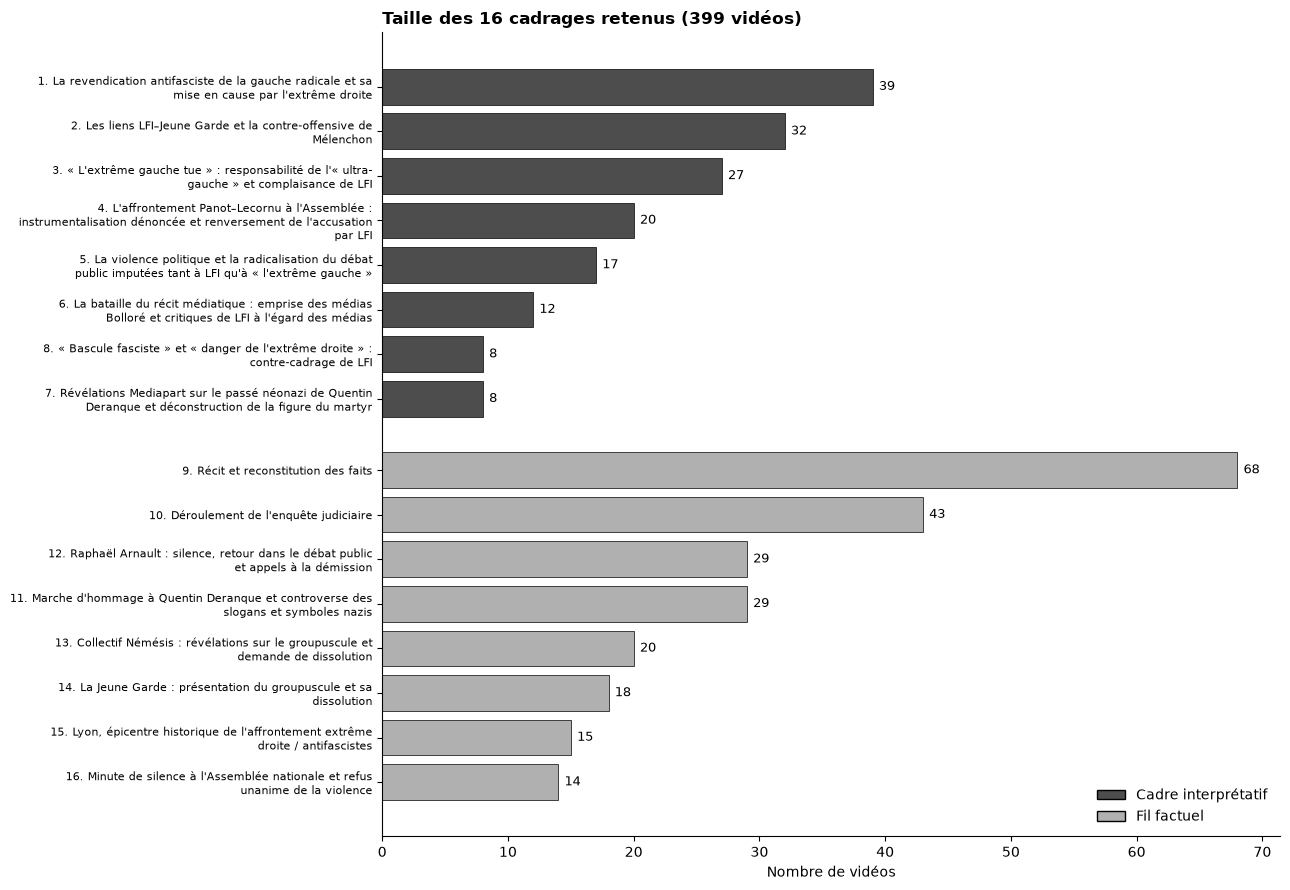

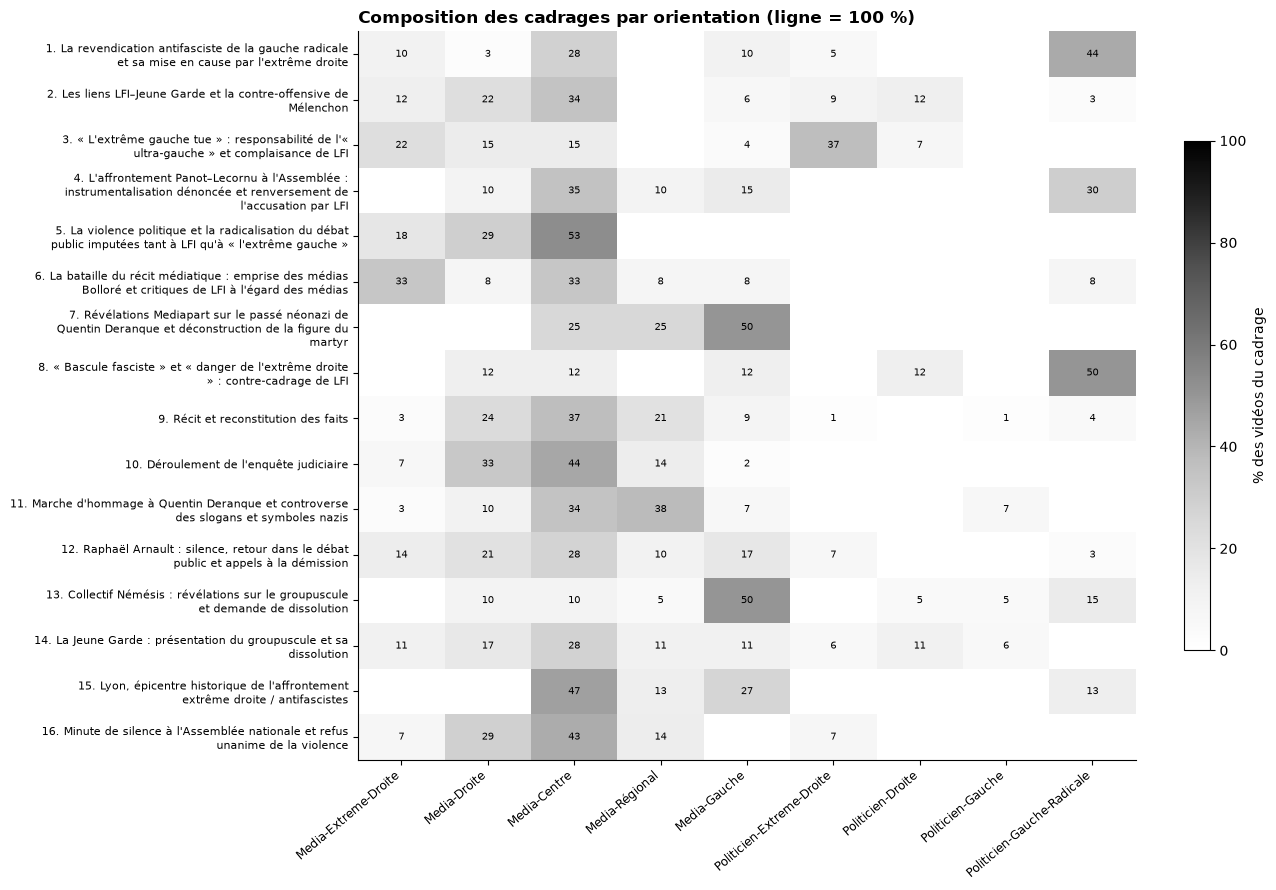

In [51]:
import matplotlib.pyplot as plt, textwrap
from matplotlib.patches import Patch
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
FIGURES_DIR = CLUSTERING_DIR / "figures_resultats"; FIGURES_DIR.mkdir(exist_ok=True)

# Numérotation stable des 16 cadrages (1-8 cadres, 9-16 fils) — référencée dans le texte
_ORDRE = [("revendication antifasciste", 1), ("contre-offensive", 2), ("l'extrême gauche tue", 3),
          ("panot", 4), ("violence politique", 5), ("récit médiatique", 6), ("mediapart", 7),
          ("bascule fasciste", 8), ("récit et reconstitution", 9), ("enquête judiciaire", 10),
          ("marche d'hommage", 11), ("raphaël arnault", 12), ("némésis", 13),
          ("présentation du groupuscule", 14), ("lyon, épicentre", 15), ("minute de silence", 16)]

def numero(lbl):
    l = str(lbl).lower()
    for key, i in _ORDRE:
        if key in l:
            return i
    return None

def libelle_num(lbl, largeur=60):        # "N. intitulé complet" avec retour à la ligne
    return textwrap.fill(f"{numero(lbl)}. {lbl}", largeur)

# Figure QR2-a : taille des cadrages (intitulés complets)
sizes = kept.groupby(["famille", "cadrage"]).size().reset_index(name="n")
sizes["num"] = sizes["cadrage"].map(numero)
# ex aequo departages par numero croissant (de haut en bas dans l'histogramme)
sizes = sizes.sort_values(["famille", "n", "num"], ascending=[True, True, False])
couleur = {"Cadre interprétatif": "#4d4d4d", "Fil factuel": "#b0b0b0"}
fig, ax = plt.subplots(figsize=(13, 9))
y, yticks, ylabels = 0, [], []
for fam in ["Fil factuel", "Cadre interprétatif"]:
    for _, r in sizes[sizes.famille == fam].iterrows():
        ax.barh(y, r["n"], color=couleur[fam], edgecolor="black", linewidth=0.5)
        ax.text(r["n"] + 0.5, y, str(r["n"]), va="center", fontsize=9)
        yticks.append(y); ylabels.append(libelle_num(r["cadrage"])); y += 1
    y += 0.6
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=8)
ax.legend(handles=[Patch(facecolor=couleur["Cadre interprétatif"], edgecolor="black", label="Cadre interprétatif"),
                   Patch(facecolor=couleur["Fil factuel"], edgecolor="black", label="Fil factuel")],
          loc="lower right", frameon=False)
ax.set_xlabel("Nombre de vidéos")
ax.set_title("Taille des 16 cadrages retenus (399 vidéos)", fontweight="bold", loc="left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qr2_tailles_cadrages.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure QR2-b : composition par orientation (intitulés complets)
ordre_cad = list(sizes.sort_values(["famille", "n", "num"], ascending=[True, False, True])["cadrage"])
ordre_orient = ["Media-Extreme-Droite", "Media-Droite", "Media-Centre", "Media-Régional", "Media-Gauche",
                "Politicien-Extreme-Droite", "Politicien-Droite", "Politicien-Gauche", "Politicien-Gauche-Radicale"]
ct = pd.crosstab(kept["cadrage"], kept["orientation_politique_macro"]).reindex(index=ordre_cad, columns=ordre_orient).fillna(0)
pct = ct.div(ct.sum(1), axis=0) * 100
fig, ax = plt.subplots(figsize=(13.5, 9))
im = ax.imshow(pct.values, cmap="Greys", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(ordre_orient))); ax.set_xticklabels(ordre_orient, rotation=40, ha="right", fontsize=8.5)
ax.set_yticks(range(len(ordre_cad)))
ax.set_yticklabels([libelle_num(c, 55) for c in ordre_cad], fontsize=8)
for i in range(len(ordre_cad)):
    for j in range(len(ordre_orient)):
        v = pct.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5, color="white" if v > 55 else "black")
cb = plt.colorbar(im, ax=ax, shrink=0.7); cb.set_label("% des vidéos du cadrage")
ax.set_title("Composition des cadrages par orientation (ligne = 100 %)", fontweight="bold", loc="left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qr2_composition_orientation.png", dpi=200, bbox_inches="tight")
plt.show()


### 6.2 QR3 — Circulation des cadrages et antériorité temporelle

Le diagramme de Sankey relie les orientations des médias (à gauche) aux cadrages (au centre) et aux orientations des acteurs politiques (à droite) ; l'épaisseur des flux est proportionnelle au nombre de vidéos. Il met en évidence la co-présence de plusieurs orientations au sein d'un même cadrage, indice central de la reprise.

In [52]:
import plotly.graph_objects as go

media = ["Media-Extreme-Droite", "Media-Droite", "Media-Centre", "Media-Régional", "Media-Gauche"]
poli  = ["Politicien-Extreme-Droite", "Politicien-Droite", "Politicien-Gauche", "Politicien-Gauche-Radicale"]
col = {"Media-Extreme-Droite": "#08306b", "Media-Droite": "#4292c6", "Media-Centre": "#969696",
       "Media-Régional": "#cccccc", "Media-Gauche": "#fb6a4a",
       "Politicien-Extreme-Droite": "#08306b", "Politicien-Droite": "#4292c6",
       "Politicien-Gauche": "#fb6a4a", "Politicien-Gauche-Radicale": "#a50f15"}

# Intitulé court des cadrages, pour l'affichage dans le Sankey (numéro + mot-clé)
COURT = {1: "Antifascisme revendiqué", 2: "LFI–Jeune Garde", 3: "« L'extrême gauche tue »",
         4: "Panot–Lecornu", 5: "Violence politique", 6: "Récit médiatique / Bolloré",
         7: "Révélations Mediapart", 8: "« Bascule fasciste »", 9: "Récit des faits",
         10: "Enquête judiciaire", 11: "Marche d'hommage", 12: "Raphaël Arnault",
         13: "Némésis", 14: "Jeune Garde", 15: "Lyon épicentre", 16: "Minute de silence"}

def rgba(h, a=0.45):
    h = h.lstrip("#"); return f"rgba({int(h[0:2],16)},{int(h[2:4],16)},{int(h[4:6],16)},{a})"

# Ordre des cadres au centre (par famille puis taille)
ordre_cad = list((kept.groupby(["famille", "cadrage"]).size().reset_index(name="n")
                      .sort_values(["famille", "n"], ascending=[True, False]))["cadrage"])
noeuds = media + ordre_cad + poli
idx = {n: i for i, n in enumerate(noeuds)}
labels = list(media) + [f"{numero(c)}. {COURT[numero(c)]}" for c in ordre_cad] + list(poli)
couleur_noeud = [col.get(n, "#dddddd") for n in media] + ["#e8e8e8"] * len(ordre_cad) + [col.get(n) for n in poli]

# Position FIXE des nœuds : x = colonne (médias 0, cadres 0.5, politiques 1),
# y = empilement calculé à partir de la taille de chaque nœud (évite tout chevauchement et
# empêche les cadres « puits » — sans lien politique — de dériver à droite).
km, kp = kept[kept.acteur_type == "media"], kept[kept.acteur_type == "politicien"]
def _n(s): return int(s.sum())
size_media = [_n(km.orientation_politique_macro == o) for o in media]
size_cad   = [max(_n(km.cadrage == c), _n(kp.cadrage == c)) for c in ordre_cad]
size_poli  = [_n(kp.orientation_politique_macro == o) for o in poli]
def ypos(sizes):
    tot = sum(sizes) or 1; ys = []; cum = 0.0
    for s in sizes:
        ys.append((cum + s / 2) / tot); cum += s
    return ys
xs = [0.001] * len(media) + [0.5] * len(ordre_cad) + [0.999] * len(poli)
ys = ypos(size_media) + ypos(size_cad) + ypos(size_poli)

S, T, V, LC = [], [], [], []
for (o, c), n in kept[kept.acteur_type == "media"].groupby(["orientation_politique_macro", "cadrage"]).size().items():
    if o in idx and c in idx:
        S.append(idx[o]); T.append(idx[c]); V.append(int(n)); LC.append(rgba(col.get(o, "#cccccc")))
for (c, o), n in kept[kept.acteur_type == "politicien"].groupby(["cadrage", "orientation_politique_macro"]).size().items():
    if o in idx and c in idx:
        S.append(idx[c]); T.append(idx[o]); V.append(int(n)); LC.append(rgba(col.get(o, "#cccccc")))

fig = go.Figure(go.Sankey(
    arrangement="fixed",
    node=dict(label=labels, x=xs, y=ys, color=couleur_noeud, pad=14, thickness=14,
              line=dict(color="black", width=0.4)),
    link=dict(source=S, target=T, value=V, color=LC)))
fig.update_layout(title_text="Médias (gauche) → cadrages (centre) → acteurs politiques (droite) — 399 vidéos ; flux = nombre de vidéos",
                  font=dict(size=11), width=1250, height=820, margin=dict(l=10, r=10, t=50, b=10))
fig.write_html(FIGURES_DIR / "qr3_sankey.html")
try:
    fig.write_image(FIGURES_DIR / "qr3_sankey.png", scale=2)   # export PNG : nécessite kaleido
except Exception as e:
    print("PNG non généré (package kaleido manquant). Le HTML est bien enregistré.\n"
          "  Pour obtenir le PNG : %pip install \"kaleido==0.2.1\"  puis relancer la cellule.\n"
          "  Détail :", e)
fig.show()

### Carte des regroupements (projection UMAP 2D)
Figure de validité (destinée au chapitre IV). Projection des embeddings des 697 vidéos en deux dimensions (UMAP, similarité cosinus), colorée par regroupement retenu ; les outliers et les regroupements écartés sont en gris. Elle donne à voir la séparation inter-cluster et la cohésion intra-cluster. La réduction à deux dimensions ne sert qu'à la visualisation, elle diffère de la réduction à cinq dimensions utilisée pour le clustering ; les axes n'ont pas de signification propre et les distances globales peuvent être déformées.

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from umap import UMAP

FIGURES_DIR = CLUSTERING_DIR / "figures_resultats"; FIGURES_DIR.mkdir(exist_ok=True)

# Données : embeddings pré-calculés + affectation canonique document -> regroupement
emb   = np.load(CLUSTERING_DIR / "embeddings_Qwen3-8b.npy")
carte = pd.read_csv(CLUSTERING_DIR / "etape1_affectations_canonique.csv", encoding="utf-8-sig")

# Numérotation des regroupements (identique aux autres figures)
_ORDRE = [("revendication antifasciste",1),("contre-offensive",2),("l'extrême gauche tue",3),("panot",4),
          ("violence politique",5),("récit médiatique",6),("mediapart",7),("bascule fasciste",8),
          ("récit et reconstitution",9),("enquête judiciaire",10),("marche d'hommage",11),("raphaël arnault",12),
          ("némésis",13),("présentation du groupuscule",14),("lyon, épicentre",15),("minute de silence",16)]
def _num(lbl):
    l = str(lbl).lower()
    for key, i in _ORDRE:
        if key in l:
            return i
    return None
carte["num"] = carte["cadrage"].map(_num)

# Projection 2D POUR LA VISUALISATION (distincte de la réduction à 5D du clustering)
xy = UMAP(n_components=2, n_neighbors=10, min_dist=0.1, metric="cosine",
          random_state=42).fit_transform(emb)
carte["x"], carte["y"] = xy[:, 0], xy[:, 1]

fig, ax = plt.subplots(figsize=(11, 9))
ax.scatter(carte.loc[carte.statut=="outlier","x"], carte.loc[carte.statut=="outlier","y"],
           s=9, c="#e2e2e2", label="Outliers", zorder=1)
ax.scatter(carte.loc[carte.statut=="exclu","x"], carte.loc[carte.statut=="exclu","y"],
           s=9, c="#b9b9b9", label="Regroupements écartés", zorder=1)
cmap = plt.get_cmap("tab20")
kept = carte[carte.statut == "garder"]
for i in range(1, 17):
    s = kept[kept.num == i]
    if len(s) == 0:
        continue
    ax.scatter(s.x, s.y, s=17, color=cmap((i-1) % 20), zorder=2)
    # étiquette placée sur le point le plus central (médoïde 2D), pas sur la moyenne
    cx, cy = s.x.mean(), s.y.mean()
    d = (s.x - cx)**2 + (s.y - cy)**2
    mx, my = s.loc[d.idxmin(), ["x", "y"]]
    ax.text(mx, my, str(i), fontsize=11, fontweight="bold", ha="center", va="center", zorder=3,
            bbox=dict(boxstyle="circle,pad=0.15", fc="white", ec="black", lw=0.6))
ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qr2_umap_map.png", dpi=200, bbox_inches="tight")
plt.show()


## Disponibilité des données et du code

Ce notebook constitue l'annexe de reproductibilité du mémoire. Les fichiers nécessaires à la réexécution du niveau 2 (à partir des embeddings) sont fournis dans le dossier `clustering/` :

- `corpus_cleaned_v1.json` et `corpus_pret_clustering.csv` : corpus des transcriptions (697 vidéos après filtrage) ;
- `embeddings_Qwen3-8b.npy` : embeddings pré-calculés (697 × 4096) ;
- `consolidation_decisions.csv` : décisions de la revue qualitative (25 topics) ;
- `etape1_affectations_canonique.csv` : affectation figée document → cadrage ;
- `rerun2june_map.json` : correspondance entre l'exécution de référence et la numérotation des topics de la revue ;
- `figures_resultats/` : figures et tableaux générés (QR2, QR3).

La génération des embeddings (niveau 1) requiert le modèle Qwen3-Embedding-8B et un GPU ; elle n'est exécutée qu'une fois, son résultat étant fourni comme artefact. Le clustering (UMAP et HDBSCAN) est déterministe (graine fixée à 42) et se rejoue sur CPU. Une réexécution reproduit la même structure à 25 topics ; de légères variations d'affectation aux marges peuvent apparaître selon les versions de librairies, sans incidence sur les 16 cadrages.
